## Homework 3

Name:

Comments for grader: 

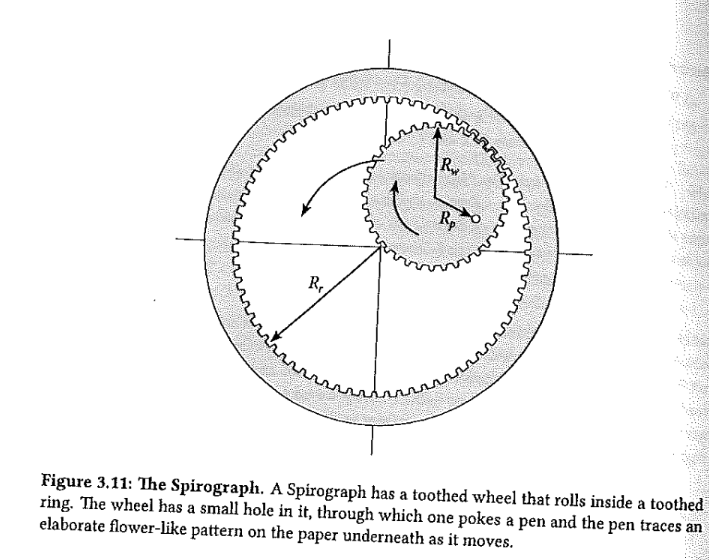

In [2]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Homework\\Figures\\fig3.11_spirograph.png"))

### Problem 1: Spirograph (this is Exercise 3.11 in 2e)

The spirograph is a classical mechanical toy, invented in the 1960s, that makes geometric drawings. A plastic ring about 15 or 20 cm across is pinned to a piece of paper. The ring has teeth around its inner rim and a small cog wheel rolls around inside this rim, meshing with the teeth and turning as it goes. The cog wheel has a hole in it, through which one can stick the tip of a ball-point pen, which draws a trail across the paper as you push the wheel around in circles. The result is a pleasing flower-like pattern, whose details can be adjusted by changing the size of the ring or the wheel. In this exercise, you will write a program to create an animation of the motion of the Spirograph and the pattern it generates.

Supose the ring of the Spirograph is centered at the origin and its inner rim has radius $R_r$, as shown in the figure. If the wheel has radius $R_w$, then the distance from the origin to the center of the wheel is $R_r-R_w$, and when the wheel has rolled an angle $\theta$ around the rim, the position $x_w, y_w$ of the center is given by

$$
x_w=(R_r-R_w)\cos\theta,
$$
$$
y_w=(R_r-R_w)\sin\theta.
$$

The distance traveled by the wheel along the inside of the rim is $\theta R_r$, so the angle $\phi$ turned by the wheel as it rolls is $\phi=-\theta R_r/R_w$, with the minus sign indicating the wheel turns in the opposite direction to its movement around the rim. If the distance between the center of the wheel and the pen hole is $R_p$, then the position of the pen hole is given by 

$$
x_p=x_w+R_p\cos\phi, 
$$
$$
y_p=y_w+R_p\sin\phi.
$$

**a)** Write a program that makes an animation showing the stationary ring, the wheel moving around the inner rim of the ring, and the pen hole as it moves, with $R_r=0.83, R_w=0.4, R_p=0.35$ (in arbitrary units). 

You may use either the ```qdraw``` or ```vpython``` package. Since ```vpython``` does not include 2D shapes like circles, you can instead use a (very) short cylinder oriented so its top or bottom is face on. 

In [ ]:
#Enter 1a code here

**/10 pts**

**b)** Add a trail to represent the line drawn by the pen, so you can see what pattern it generates. To better view the pattern, you may wish to remove the ring and wheel after drawing, or if you are using ```vpython```, decrease the opacity of the wheel so you can see the pattern underneath as it moves. 

In [1]:
#Enter 1b code here

**/5 pts**

**c)** Vary the values of the three radii $R_r, R_w, $ and $R_p$ and find a setting that produces an interesting pattern. 

In [ ]:
#Enter 1c code here

**/5 pts**

**Total Problem 1: /20 pts**

## Exercise 4.3: Numerical derivative

The definition of the derivative of function $f(x)$ is:

\begin{equation*}
{ df\over dx} = \lim_{\delta\to0} {f(x+\delta)-f(x)\over\delta}.
\end{equation*}

On the computer we can't actually take the limit as $\delta$ goes to zero, but we can get a reasonable approximation just by making $\delta$
small.

*a)* Write a function *deriv()* that uses this definition to estimate the derivative of some function $f(x)$ at a user-specified point $x$. Pass the following arguments to *deriv()*: the function $f$ you will differentiate, the point $x$ at which you will evaluate the derivative, and $\delta$. 

Use your function to evaluate the derivative of $f(x) = x(x-1)$ at $x=-1$ using $\delta=10^{-14}$. You should pass this function to *deriv()*. Have your program *neatly* output the numerical value of the derivative, the exact value of the derivative determined analytically by you, and the percent relative error of your estimate.

In [ ]:
#Type your code here

x = -1
delta = 10**(-4)

def f(x):
    return x*(x-1)

def deriv(func, x, delta):
    return (func(x+ delta) - func(x))/delta

def real_deriv(x):
    return 2 * x - 1

def accuracy(func, x, delta):
    real_value = real_deriv(x)
    der_value = deriv(func, x, delta)
    return 100 * abs(real_value - der_value)/real_value 

def run(func, x, delta):
    der_value = deriv(func, x, delta)
    print("Numerical Value of the Derivative: {der_value:0.2f}")
    real_value = real_deriv(x)
    print("Actual Derivative determined analytically: {real_value:0.3f}")
    approx = 100 * abs(real_value - der_value)/real_value
    print(f"Percent relative error: {approx:0.3f}")

run(f, x, delta)

Numerical Value of the Derivative: {der_value:0.2f}
Actual Derivative determined analytically: {real_value:0.3f}
Percent relative error: -0.003


**Pts /5**

**b)** Repeat the calculation for a range of $\delta$'s from  $\delta=10^{-2}$ to  $10^{-14}$ and calculate the percent relative error for each. Note, because this is such a large range, you will need to step through $\delta$ logarithmically. Make a plot of the error vs. $\delta$. Label your axes appropriately and use a log scale for both axes. 

You should find an interesting relationship between the error on the derivative and $\delta$. Provide an explanation for this. 

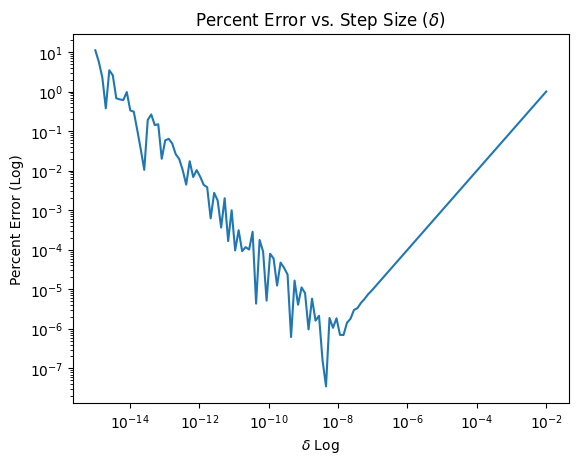

In [19]:
#Exercise 4.3b
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x*(x-1)

def deriv(func, x, delta):
    return (func(x + delta) - func(x))/delta

def real_deriv(x):
    return 2 * x - 1

def percent_error(func, x, delta):
    real_value = real_deriv(x)
    der_value = deriv(func, x, delta)
    return 100 * abs(real_value - der_value)/real_value 

def display_accuracies(func, x, delta_arrays):
    percent_error_array = percent_error(func, x, delta_arrays) 

    plt.loglog(delta_arrays, percent_error_array)
    plt.xlabel(r"$\delta$ Log")
    plt.ylabel(r"Percent Error (Log)")
    plt.title(r"Percent Error vs. Step Size ($\delta$)")
    plt.show()

delta_arrays = np.geomspace(10**(-2), 10**(-15), 130)

display_accuracies(f, 1, delta_arrays)
   


**Explanation of plot:**


From the Percent Error Vs Step Size ($\delta$) one can see that the percent error reaches a minimum around $10^{-9}$. Although I can not tell the exact reason why this occurs perhaps this has to do with how python deals with problems that approach $0/0$, the root cause is mostlikely machine precision.

**Pts /5**

**Total Exercise Pts /10**

## Trapezoid and Simpson's Rules

Compare the results of estimating an integral using the trapezoid rule and Simpson's rule. Write a function for both methods. Both functions should take as arguments the function  to integrate $f$, the integration limits $a,b$,  and the number of slices $N$.

**a)** Use your functions to estimate the integral

$$
\int^3_1 \frac{1}{x^2}dx 
$$

over a range of $N$ until the results converge. Plot the percent relative error of the integral vs. $N$ for both the Simpson's rule and the trapezoidal rule on the same plot.

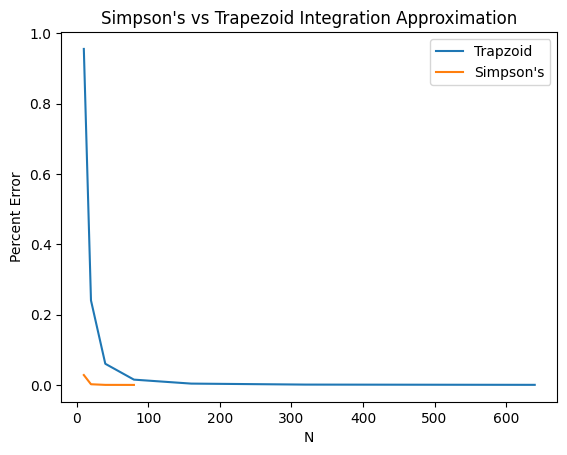

In [25]:
# trapezoid and Simpson's rule code
import numpy as np
import matplotlib.pyplot as plt

def func(x):
    return 1 / (x**2)

def percent_error(approx_val, true_val): 
    return 100 * (approx_val - true_val) / true_val

def trapzoid(func, a, b, N):
    h = (b - a)/ N
    s = h/2 * (func(a) + func(b))
    s += h * np.sum(func(a + (np.arange(1, N) * h)))
    return s

def simpsons(func, a, b, N):
    h = (b - a)/ N
    s = h/3 * (func(a) + func(b))   
    s += h * 2/3 * np.sum(func(a + (np.arange(2, N-1, 2) * h))) 
    s += h * 4/3 * np.sum(func(a + (np.arange(1, N, 2) * h))) 
    return s

def converge(approx_I_func, func, correct_I_val, a, b, epsilon):
    N = 10
    N_list = [N]
    I_old = approx_I_func(func, a, b, N)
    p_error = percent_error(I_old, correct_I_val)
    percent_error_list = [p_error]
    
    flag = True
    
    while(flag): 
        N *= 2
        N_list.append(N)
        I_new = approx_I_func(func, a, b, N)
        p_error = percent_error(I_new, correct_I_val)
        percent_error_list.append(p_error)
        
        if(abs(I_new - I_old) < epsilon):
            flag = False
        
        I_old = I_new
    
    return N_list, percent_error_list

def run():
    correct_I_val = 2/3
    a = 1
    b = 3
    epsilon = 1e-5

    N_list_t, percent_error_list_t = converge(trapzoid, func, correct_I_val, a, b, epsilon)
    plt.plot(N_list_t, percent_error_list_t, label="Trapzoid")
    plt.xlabel("N")
    plt.ylabel("Percent Error")
   
    N_list_s, percent_error_list_s = converge(simpsons, func, correct_I_val, a, b, epsilon)
    plt.plot(N_list_s, percent_error_list_s, label="Simpson's")
    plt.xlabel("N")
    plt.ylabel("Percent Error")
    
    plt.title("Simpson's vs Trapezoid Integration Approximation") 
    plt.legend()
    plt.show()

run()


**Pts /10**

**b)** Repeat for the integral:

$$
\int^{6.9}_0 \cos(\frac{\pi}{2}x^2)dx
$$

This function is the *Fresnel Cosine Integral*, used in optics. It may be helpful in understanding what's going on with your integration if you make a graph of the function. 

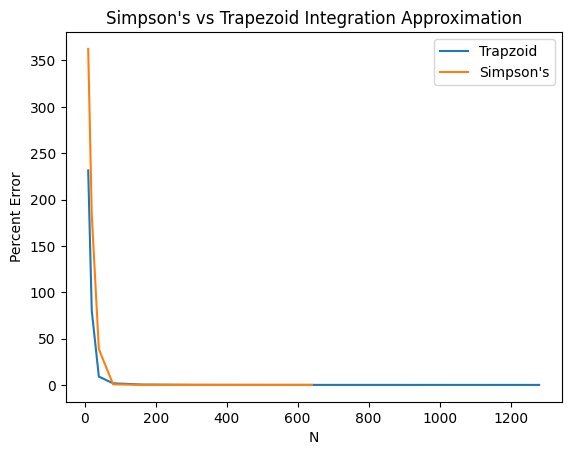

In [ ]:
# trapezoid and Simpson's rule code
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def func(x):
    return np.cos(np.pi/2 * x **2)

def percent_error(approx_val, true_val): 
    return np.abs(100 * (approx_val - true_val) / true_val)

def trapzoid(func, a, b, N):
    h = (b - a)/ N
    s = h/2 * (func(a) + func(b))
    s += h * np.sum(func(a + (np.arange(1, N) * h)))
    return s

def simpsons(func, a, b, N):
    h = (b - a)/ N
    s = h/3 * (func(a) + func(b))   
    s += h * 2/3 * np.sum(func(a + (np.arange(2, N-1, 2) * h))) 
    s += h * 4/3 * np.sum(func(a + (np.arange(1, N, 2) * h))) 
    return s

def converge(approx_I_func, func, correct_I_val, a, b, epsilon):
    N = 10
    N_list = [N]
    I_old = approx_I_func(func, a, b, N)
    p_error = percent_error(I_old, correct_I_val)
    percent_error_list = [p_error]
    
    flag = True
    
    while(flag): 
        N *= 2
        N_list.append(N)
        I_new = approx_I_func(func, a, b, N)
        p_error = percent_error(I_new, correct_I_val)
        percent_error_list.append(p_error)
        
        if(abs(I_new - I_old) < epsilon):
            flag = False
        
        I_old = I_new
    
    return N_list, percent_error_list

def run():
    # We use a better approximation function for our correct value.
    correct_I_val, error = quad(func, 0, 6.9)
    a = 0
    b = 6.9
    epsilon = 1e-4

    N_list_t, percent_error_list_t = converge(trapzoid, func, correct_I_val, a, b, epsilon)
    plt.plot(N_list_t, percent_error_list_t, label="Trapzoid")
    plt.xlabel("N")
    plt.ylabel("Percent Error")
   
    N_list_s, percent_error_list_s = converge(simpsons, func, correct_I_val, a, b, epsilon)
    plt.plot(N_list_s, percent_error_list_s, label="Simpson's")
    plt.xlabel("N")
    plt.ylabel("Percent Error")
    
    plt.title("Simpson's vs Trapezoid Integration Approximation") 
    plt.legend()
    plt.show()

run()


**Pts /5**

**Total Pts /15**

## Exercise 5.4

Our ability to resolve detail in astronomical observations is
limited by the diffraction of light in our telescopes.  Light from stars
can be treated effectively as coming from a point source at infinity.  When
such light, with wavelength $\lambda$, passes through the circular aperture
of a telescope (which we'll assume to have unit radius) and is focused by
the telescope in the focal plane, it produces not a single dot, but a
circular diffraction pattern consisting of central spot surrounded by a
series of concentric rings.  The intensity of the light in this diffraction
pattern is given by

\begin{equation*}
I(r) = \biggl( {J_1(kr)\over kr} \biggr)^2,
\end{equation*}

where $r$ is the distance in the focal plane from the center of the
diffraction pattern, $k=2\pi/\lambda$, and $J_1(x)$ is a Bessel function.
The Bessel functions $J_m(x)$ are given by

\begin{equation*}
J_m(x) = {1\over\pi} \int_0^\pi \cos(m\theta - x\sin\theta) \>d\theta,
\end{equation*}

where $m$ is a nonnegative integer and $x\ge0$.

**a)** Write a Python function _J(m,x)_ that calculates the value of
  $J_m(x)$ using Simpson's rule with $N=1000$ points.  Use your
  function in a program to make a plot, on a single graph, of the Bessel
  functions $J_0$, $J_1$, and $J_2$ as a function of $x$ from $x=0$ to
  $x=20$.

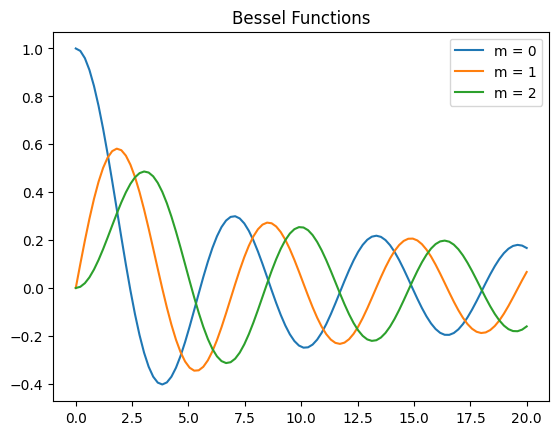

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Note that our function is being integrated over thetat not x.
def func(theta, m, x):
    return np.cos(m * theta - x * np.sin(theta))

def simpsons(func, a, b, m, x, N):
    h = (b - a)/ N
    s = h/3 * (func(a, m, x) + func(b, m, x))   
    s += h * 2/3 * np.sum(func(a + (np.arange(2, N-1, 2) * h), m, x)) 
    s += h * 4/3 * np.sum(func(a + (np.arange(1, N, 2) * h), m, x)) 
    return s

def J(x, m):
    # For a given x and m we need to approximate an inner integral
    N = 1000
    theta_a = 0
    theta_b = np.pi
    
    approx_int = 1 / np.pi * simpsons(func, theta_a, theta_b, m, x, N) 
    
    return approx_int

J = np.vectorize(J)

def display(x_start, x_end):
    
    x_range = np.linspace(x_start, x_end, 100)
    J_range_0 = J(x_range, 0)
    J_range_1 = J(x_range, 1)
    J_range_2 = J(x_range, 2)

    plt.plot(x_range, J_range_0, label="m = 0")
    plt.plot(x_range, J_range_1, label="m = 1")
    plt.plot(x_range, J_range_2, label="m = 2")
    plt.xlabel("")
    plt.legend()
    plt.title("Bessel Functions")
    plt.show()

display(0, 20)

    
    

    

**Pts /10**

**b)** Make a second program that makes a density plot of the intensity of
  the circular diffraction pattern of a point light source with
  $\lambda=500\,$ nm, in a square region of the focal plane, using the
  formula given above.  Your picture should cover values of $r$ from zero
  up to about $1\,\mu$ m.
  
Hint: The central spot in the
diffraction pattern is so bright that it may be difficult to see the rings around it on the computer
screen. If you run into this problem a simple way to deal with it is to use one of the other color
schemes for density plots described in Section 3.3. The “hot” scheme works well. For a more
sophisticated solution to the problem, the imshow function has an additional argument vmax
that allows you to set the value that corresponds to the brightest point in the plot. For instance,
if you say “imshow(x,vmax=0.1)”, then elements in x with value 0.1, or any greater value, will
produce the brightest (most positive) color on the screen. By lowering the vmax value, you can
reduce the total range of values between the minimum and maximum brightness, and hence
increase the sensitivity of the plot, making subtle details visible. (There is also a vmin argument
that can be used to set the value that corresponds to the dimmest (most negative) color.) For
this exercise a value of vmax=0.01 appears to work well.
  

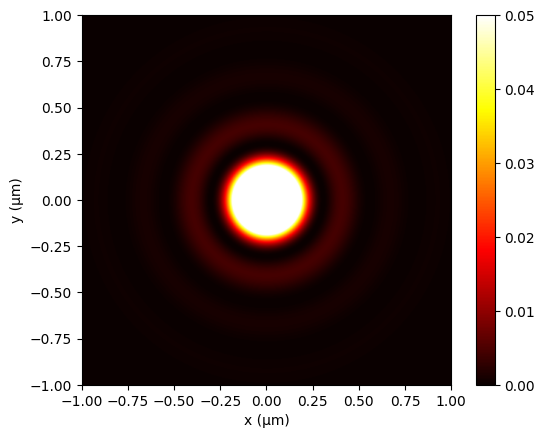

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Note that our function is being integrated over thetat not x.
def func(theta, m, x):
    return np.cos(m * theta - x * np.sin(theta))

def simpsons(func, a, b, m, x, N):
    h = (b - a)/ N
    s = h/3 * (func(a, m, x) + func(b, m, x))   
    s += h * 2/3 * np.sum(func(a + (np.arange(2, N-1, 2) * h), m, x)) 
    s += h * 4/3 * np.sum(func(a + (np.arange(1, N, 2) * h), m, x)) 
    return s

def J(x, m):
    # For a given x and m we need to approximate an inner integral
    N = 1000
    theta_a = 0
    theta_b = np.pi
    
    approx_int = 1 / np.pi * simpsons(func, theta_a, theta_b, m, x, N) 
    
    return approx_int

J = np.vectorize(J)

def gen_r(X, Y):
    return np.sqrt(X**2 + Y**2) # Works with 2D arrays

def gen_intensity():
    # Build my 2D Grid!
    coords = np.linspace(-1e-6, 1e-6, 500)
    X,Y = np.meshgrid(coords, coords)
    
    # Generate 2D distance matrix
    r_matrix = gen_r(X,Y)

    # Generate Intensity Matrix
    wavelength = 500e-9
    k = 2 * np.pi/ (wavelength)

    I = np.where(r_matrix == 0, 0.25, (J(k*r_matrix, 1) / (k*r_matrix))**2)


    # Need to correct 

    return I

def run_display():
    I = gen_intensity()

    plt.imshow(I, extent=(-1,1,-1,1), cmap ='hot', vmax=0.05, origin ='lower')
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.colorbar()
    plt.show()
    
run_display()

**Pts /10**

In [1]:
print("Hello")

Hello


**Total Exercise Pts /20**

I used AI to help me fix some bugs in my code and to help me with syntax. I also wanted to learn how to use np operations on arrays to avoid for loops accros matrix elements. I find this to be much clearner code and simplifies it. 

## Total HW Pts /65